In [3]:
import sys
!{sys.executable} -m pip install shap

     -------------------------------------- 547.0/547.0 kB 4.9 MB/s eta 0:00:00
     ---------------------------------------- 2.7/2.7 MB 17.5 MB/s eta 0:00:00
     --------------------------------------- 38.1/38.1 MB 22.6 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import shap

c:\Users\praji_\Desktop\files\fyp\project\Emergency_Triage_MIMIC_Real\venv_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import pickle
import joblib
import numpy as np

# Load model
xgb_model = pickle.load(open("xgb_model.pkl", "rb"))

# Load vectorizer (FIXED)
tfidf = joblib.load("tfidf_vectorizer.pkl")

# Load embeddings
X_test = np.load("test_clinicalbert_embeddings.npy")

In [10]:
import shap

# Use a small background sample (VERY IMPORTANT)
background = X_test[:50]

explainer = shap.Explainer(
    xgb_model.predict_proba,   # callable
    background
)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("../data/processed_real_mimic_ed.csv")
df = df.dropna(subset=["chiefcomplaint"])

# Same split as training
y = df["acuity"]
X_structured = df.drop(columns=["acuity", "chiefcomplaint"])

X_struct_train, X_struct_test, y_train, y_test = train_test_split(
    X_structured,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [2]:
import joblib

# Load saved scaler
scaler = joblib.load("scaler.pkl")

# Scale test data
X_struct_test_scaled = scaler.transform(X_struct_test)

In [5]:
import joblib
import shap

# Load model
xgb_model = joblib.load("xgb_model.pkl")

# Background data
background = X_struct_test_scaled[:50]

# Create explainer
explainer = shap.Explainer(
    xgb_model.predict_proba,
    background
)

In [6]:
# Small sample for explanation
sample_data = X_struct_test_scaled[:10]

shap_values = explainer(
    sample_data,
    max_evals=600
)

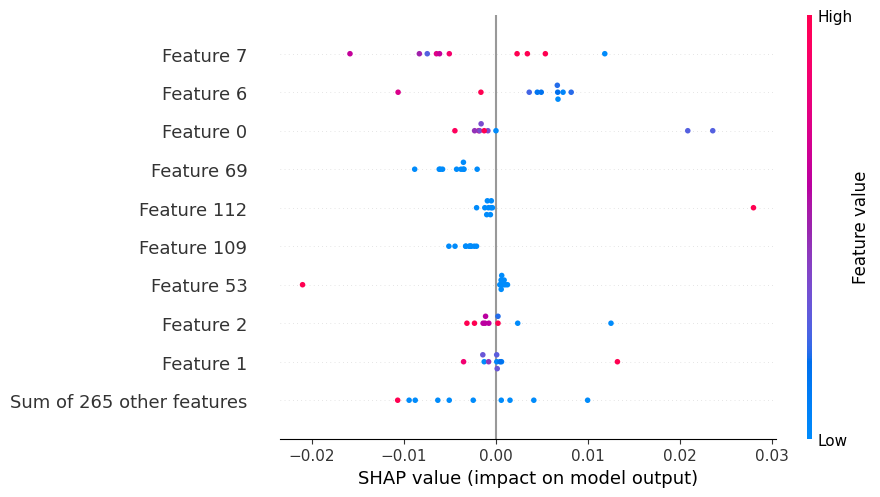

In [8]:
# Select class 0 (you can change later)
shap.plots.beeswarm(shap_values[:, :, 0])